In [9]:
# Cell 1 — Imports
import json
import time
import requests
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from pyinaturalist import get_taxa, get_observations
from tqdm import tqdm
from PIL import Image
import boto3
from dotenv import load_dotenv
import os

In [ ]:
IMAGES_PER_SPECIES = 500
DOWNLOAD_DIR = Path("/Volumes/kaggle/inat_fish")
DOWNLOADED_IDS_FILE = DOWNLOAD_DIR / "downloaded_ids.json"
MAX_WORKERS = 20

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Cell 2 — Query Pacific/freshwater fish from iNaturalist
results = get_taxa(
    taxon_id=47178,   # Actinopterygii - ray-finned fish
    place_id=59,      # California coast
    rank="species",
    per_page=200,
    order_by="observations_count",
    order="desc"
)

qualified = []
for taxon in results['results']:
    name = taxon['name']
    common = taxon.get('preferred_common_name', 'no common name')
    obs_count = taxon.get('observations_count', 0)
    taxon_id = taxon.get('id')
    if obs_count >= 500:
        qualified.append({
            'name': name,
            'common': common,
            'count': obs_count,
            'taxon_id': taxon_id
        })

print(f"Total qualified species: {len(qualified)}")

Total qualified species: 200


In [3]:
# Cell 3 — Add Pacific mackerel species manually
extra_species = [
    {'name': 'Scomber japonicus', 'common': 'Pacific Chub Mackerel', 'count': 607, 'taxon_id': 69840},
    {'name': 'Trachurus symmetricus', 'common': 'Pacific Jack Mackerel', 'count': 300, 'taxon_id': 114274},
]
qualified.extend(extra_species)
print(f"Total species with mackerel: {len(qualified)}")

Total species with mackerel: 202


In [4]:
# Cell 4 — Filter to species with common names only
final_species = [s for s in qualified if s['common'] != 'no common name']
print(f"Final species count: {len(final_species)}")
for i, s in enumerate(final_species, 1):
    print(f"{i:3}. {s['common']:40} {s['name']:35} {s['count']:,}")

Final species count: 202
  1. Bluegill                                 Lepomis macrochirus                 59,256
  2. Largemouth Bass                          Micropterus nigricans               39,881
  3. European Carp                            Cyprinus carpio                     32,794
  4. Rainbow Trout                            Oncorhynchus mykiss                 24,805
  5. Amur Carp                                Cyprinus rubrofuscus                22,019
  6. Western Mosquitofish                     Gambusia affinis                    19,964
  7. Green Sunfish                            Lepomis cyanellus                   19,651
  8. Pumpkinseed                              Lepomis gibbosus                    17,960
  9. Smallmouth Bass                          Micropterus dolomieu                17,296
 10. Bluefin Leatherjacket                    Thamnaconus degeni                  17,227
 11. Goldfish                                 Carassius auratus                   16,

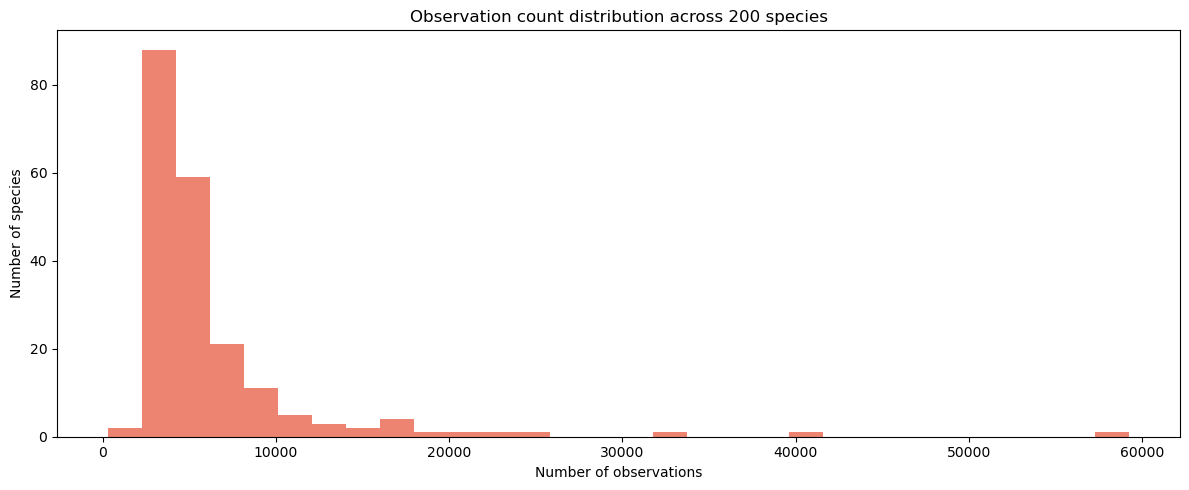

Min observations: 300
Max observations: 59256
Median observations: 4450
Species with 1000+: 200
Species with 2000+: 200


In [5]:
# Cell 5 — Distribution plot
counts = [s['count'] for s in qualified]
plt.figure(figsize=(12, 5))
plt.hist(counts, bins=30, color='#e8664d', alpha=0.8)
plt.xlabel('Number of observations')
plt.ylabel('Number of species')
plt.title('Observation count distribution across 200 species')
plt.tight_layout()
plt.savefig('../outputs/species_distribution.png')
plt.show()

print(f"Min observations: {min(counts)}")
print(f"Max observations: {max(counts)}")
print(f"Median observations: {np.median(counts):.0f}")
print(f"Species with 1000+: {sum(1 for c in counts if c >= 1000)}")
print(f"Species with 2000+: {sum(1 for c in counts if c >= 2000)}")

In [6]:
# Cell 6 — Download helpers
def load_downloaded_ids():
    if DOWNLOADED_IDS_FILE.exists():
        with open(DOWNLOADED_IDS_FILE) as f:
            return set(json.load(f))
    return set()

def save_downloaded_ids(ids):
    with open(DOWNLOADED_IDS_FILE, 'w') as f:
        json.dump(list(ids), f)

def download_image(args):
    obs_id, url, filepath = args
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            with open(filepath, 'wb') as f:
                f.write(r.content)
            return obs_id, True
    except Exception:
        pass
    return obs_id, False

In [7]:
# Cell 7 — Main download loop
downloaded_ids = load_downloaded_ids()
print(f"Loaded {len(downloaded_ids)} previously downloaded IDs")

for species in final_species:
    name = species['name']
    common = species['common']
    species_dir = DOWNLOAD_DIR / name.replace(' ', '_')
    species_dir.mkdir(exist_ok=True)

    existing = list(species_dir.glob("*.jpg"))
    if len(existing) >= IMAGES_PER_SPECIES:
        print(f"✓ Skipping {common} — already have {len(existing)} images")
        continue

    needed = IMAGES_PER_SPECIES - len(existing)

    # Collect download tasks
    tasks = []
    page = 1
    while len(tasks) < needed + 50:
        obs = get_observations(
            taxon_name=name,
            quality_grade="research",
            photos=True,
            per_page=200,
            page=page
        )
        if not obs['results']:
            break
        for o in obs['results']:
            obs_id = str(o['id'])
            if obs_id in downloaded_ids or not o.get('photos'):
                continue
            photo_url = o['photos'][0]['url'].replace('square', 'medium')
            filepath = species_dir / f"{obs_id}.jpg"
            if not filepath.exists():
                tasks.append((obs_id, photo_url, filepath))
        page += 1

    # Download concurrently with progress bar
    count = len(existing)
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(download_image, task): task for task in tasks}
        with tqdm(total=needed, desc=f"{common[:35]:35}", unit="img") as pbar:
            for future in as_completed(futures):
                if count >= IMAGES_PER_SPECIES:
                    break
                obs_id, success = future.result()
                if success:
                    downloaded_ids.add(obs_id)
                    count += 1
                    pbar.update(1)

    save_downloaded_ids(downloaded_ids)
    print(f"  ✓ {common}: {count}/{IMAGES_PER_SPECIES} images")

print("\nAll done!")
print(f"Total species: {len(list(DOWNLOAD_DIR.iterdir())) - 1}")
print(f"Total images: {len(list(DOWNLOAD_DIR.rglob('*.jpg')))}")

Loaded 96642 previously downloaded IDs
✓ Skipping Bluegill — already have 500 images
✓ Skipping Largemouth Bass — already have 500 images
✓ Skipping European Carp — already have 500 images
✓ Skipping Rainbow Trout — already have 500 images
✓ Skipping Amur Carp — already have 500 images
✓ Skipping Western Mosquitofish — already have 600 images
✓ Skipping Green Sunfish — already have 500 images
✓ Skipping Pumpkinseed — already have 500 images
✓ Skipping Smallmouth Bass — already have 500 images
✓ Skipping Bluefin Leatherjacket — already have 500 images
✓ Skipping Goldfish — already have 500 images
✓ Skipping Eastern Mosquitofish — already have 756 images
✓ Skipping Brown Trout — already have 1000 images
✓ Skipping Creek Chub — already have 999 images
✓ Skipping Northern Pike — already have 1000 images
✓ Skipping Brook Trout — already have 1177 images
✓ Skipping Channel Catfish — already have 1000 images
✓ Skipping Moorish Idol — already have 1000 images
✓ Skipping Atlantic Sergeant Major

Siamese Fighting Fish              :   0%|                       | 0/463 [00:00<?, ?img/s]


  ✓ Siamese Fighting Fish: 37/500 images
✓ Skipping Lemon Damsel — already have 600 images
✓ Skipping Blacksaddle Toby — already have 600 images
✓ Skipping Yellowfin Bream — already have 600 images
✓ Skipping Four-eyed Butterflyfish — already have 600 images
✓ Skipping Hawaiian Convict Surgeonfish — already have 604 images
✓ Skipping Vagabond Butterflyfish — already have 600 images
✓ Skipping Yellow Tang — already have 600 images
✓ Skipping Eastern Blue Groper — already have 600 images
✓ Skipping Ringneck Blenny — already have 600 images
✓ Skipping Bridled Monocle Bream — already have 599 images
✓ Skipping Smooth Trunkfish — already have 560 images
✓ Skipping Bar Jack — already have 600 images
✓ Skipping Bleak — already have 600 images
✓ Skipping Emperor Angelfish — already have 600 images
✓ Skipping Tompot Blenny — already have 600 images
✓ Skipping Cortez Rainbow Wrasse — already have 600 images
✓ Skipping Blackeye Thicklip — already have 600 images
✓ Skipping White Perch — already h

Pacific Jack Mackerel              :   0%|                       | 0/223 [00:00<?, ?img/s]


  ✓ Pacific Jack Mackerel: 277/500 images

All done!
Total species: 203
Total images: 180962


In [12]:
# Cell 8 — Image quality audit (concurrent)
def audit_image(img_path):
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            if w < 100 or h < 100:
                return img_path, f"too small: {w}x{h}"
            if img.mode not in ['RGB', 'RGBA']:
                return img_path, f"bad mode: {img.mode}"
    except Exception as e:
        return img_path, f"corrupted: {e}"
    return img_path, None

print("Scanning for images...")
all_images = list(DOWNLOAD_DIR.rglob("*.jpg"))
print(f"Found {len(all_images)} images — starting audit...")

issues = []
checked = 0
removed = 0

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(audit_image, img): img for img in all_images}
    with tqdm(
        total=len(all_images),
        desc="Auditing",
        unit="img",
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] issues: {postfix}"
    ) as pbar:
        for future in as_completed(futures):
            img_path, reason = future.result()
            checked += 1
            if reason:
                issues.append((img_path, reason))
            pbar.set_postfix_str(f"{len(issues)} issues found")
            pbar.update(1)

print(f"\nAudit complete — {checked} images checked")
print(f"Total issues found: {len(issues)}")

for path, reason in issues[:20]:
    print(f"  {reason} — {path.name}")

if issues:
    for path, reason in issues:
        path.unlink()
        removed += 1
    print(f"\nRemoved {removed} bad images")
    print(f"Clean images remaining: {len(all_images) - removed}")
else:
    print("All images passed quality check ✓")

Scanning for images...
Found 180962 images — starting audit...


Auditing: 100%|█████| 180962/180962 [1:16:40<00:00, 39.34img/s] issues: , 167 issues found



Audit complete — 180962 images checked
Total issues found: 167
  too small: 144x84 — 348289157.jpg
  too small: 103x71 — 336302207.jpg
  too small: 167x64 — 348289182.jpg
  too small: 126x66 — 345324413.jpg
  too small: 156x84 — 343533283.jpg
  too small: 173x71 — 348289064.jpg
  too small: 116x96 — 342592703.jpg
  bad mode: P — 340340589.jpg
  bad mode: P — 329355112.jpg
  too small: 125x79 — 348289143.jpg
  too small: 99x95 — 334800047.jpg
  too small: 136x91 — 336999825.jpg
  bad mode: P — 366114953.jpg
  too small: 160x94 — 340091630.jpg
  too small: 142x68 — 340091629.jpg
  too small: 208x80 — 340081017.jpg
  too small: 106x88 — 343217706.jpg
  too small: 84x62 — 340081018.jpg
  bad mode: P — 323840305.jpg
  too small: 196x65 — 350782153.jpg

Removed 167 bad images
Clean images remaining: 180795


In [ ]:
# Cell 9 — Create AIStor bucket and upload dataset
load_dotenv()

s3 = boto3.client(
    's3',
    endpoint_url=os.getenv('AISTOR_ENDPOINT'),
    aws_access_key_id=os.getenv('AISTOR_ACCESS_KEY'),
    aws_secret_access_key=os.getenv('AISTOR_SECRET_KEY')
)

# Create bucket
s3.create_bucket(Bucket='fish-classifier-expanded')
print("Bucket created")

In [ ]:
def upload_image(args):
    img_path, bucket, key = args
    try:
        s3.upload_file(str(img_path), bucket, key)
        return key, True
    except Exception as e:
        return key, False

print("Scanning images for upload...")
all_images = [p for p in DOWNLOAD_DIR.rglob("*.jpg")]
print(f"Found {len(all_images)} images — uploading to AIStor...")

tasks = []
for img_path in all_images:
    species = img_path.parent.name
    key = f"raw/{species}/{img_path.name}"
    tasks.append((img_path, 'fish-classifier-expanded', key))

failed = []
uploaded = 0

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(upload_image, task): task for task in tasks}
    with tqdm(
        total=len(tasks),
        desc="Uploading",
        unit="img",
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] failed: {postfix}"
    ) as pbar:
        for future in as_completed(futures):
            key, success = future.result()
            if success:
                uploaded += 1
            else:
                failed.append(key)
            pbar.set_postfix_str(f"{len(failed)}")
            pbar.update(1)

print(f"\nUpload complete")
print(f"Uploaded: {uploaded}")
print(f"Failed: {len(failed)}")
if failed:
    print("Failed keys:")
    for k in failed[:10]:
        print(f"  {k}")